# Taller Discursos Presidenciales PLN

## Grupo 1

Abel Albuez  
Kelly Leon  
Juan Camilo Torres  
Jesús David Romero

In [4]:
!pip install nltk spacy matplotlib wordcloud pandas textstat==0.2 textdescriptives networkx jupyter

  Using cached spacy-3.8.13-cp314-cp314-win_amd64.whl.metadata (28 kB)
  Using cached wordcloud-1.9.6-cp314-cp314-win_amd64.whl.metadata (3.5 kB)
  Using cached textstat-0.2.tar.gz (15 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached textdescriptives-2.8.4-py3-none-any.whl.metadata (25 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.15-cp314-cp314-win_amd64.whl.metadata (2.3 kB)
  Using cached cymem-2.0.13-cp314-cp314-win_amd64.whl.me

In [3]:
!pip install open_corpus_co_es

### Obteniendo el corpus de presidentes

In [5]:
from open_corpus_co_es.loader import load_corpus, list_corpus
from open_corpus_co_es.downloader import download_corpus

print(f"Corpus disponibles: {list_corpus()}")
nombre = "presidentes"

print(f"\n📥 Descargando y cargando corpus: {nombre}")
download_corpus(nombre, force=True)
datos = load_corpus(nombre)
print("\n✅ Corpus cargado correctamente\n")
print(f"\n📄 Primer documento: {datos[:1]}")

INFO - ⬇️ Cargando corpus 'presidentes'...


Corpus disponibles: {'dataset_bancos_2022': {'tipo': 'corpora', 'origen': 'tweets', 'extension': 'parquet', 'pais': 'Colombia', 'año': 2022, 'tema': 'Financiero', 'tokenizacion': 'Post', 'descripcion': "Financiero - Conjunto de datos de origen 'Tweets' generado en Colombia durante el año 2022.", 'enabled': True}, 'perfiles_periodistas_2020': {'tipo': 'corpora', 'origen': 'tweets', 'extension': 'parquet', 'pais': 'Colombia', 'año': 2020, 'tema': 'Perfiles', 'tokenizacion': 'Post', 'descripcion': "Perfiles - Conjunto de datos de origen 'Tweets' generado en Colombia durante el año 2020.", 'enabled': True}, 'tweets_miscelaneos_2020': {'tipo': 'corpora', 'origen': 'tweets', 'extension': 'parquet', 'pais': 'Colombia', 'año': 2020, 'tema': 'Tweets', 'tokenizacion': 'Post', 'descripcion': "Tweets - Conjunto de datos de origen 'Tweets' generado en Colombia durante el año 2020.", 'enabled': True}, 'educacion_argentina_2024_v2': {'tipo': 'corpora', 'origen': 'tweets', 'extension': 'parquet', 'pai

INFO - ✔️ Recurso o corpus 'presidentes' agregado correctamente. Omitiendo validación de estructura.



✅ Corpus cargado correctamente


📄 Primer documento: [{'text': '"pueblos, por vuestra victoria moral ¡a la carga!, por la restauración moral ¡a la carga!, por vuestra victoria ¡a la carga!, por la derrota de la oligarquía ¡a la carga!\npor la razón por la cual este movimiento no es personalista sino doctrinario, por la razón elemental de que tiene que terminar de una vez el hecho primitivo, el hecho indecoroso para mi patria, que es un gran pueblo, de que se le maneja con el irrespeto con que se manejan las vacadas de las haciendas privadas. los hombres colombianos no podemos ser manejados con ese irrespeto, es nuestra dignidad que está por encima de los partidos, que está por encima de los cápulos monumentarios, que está por encima de las papeletas, porque donde no hay dignidad del hombre todo lo demás está perdido.\npero no resultó tampoco aquella maniobra, que tenía nombre propio y en esta tarde me he encontrado con el caso singular, de los enterradores convertidos en parteras de n

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
INFO: pip is looking at multiple versions of textdescriptives to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/14.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.4 MB ? eta -:--:--
   --------------------------

### Nube de palabras

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jesus.romerom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


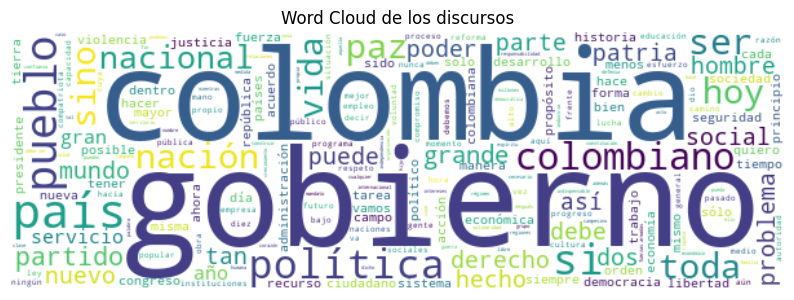

In [ ]:
from  nltk.corpus import stopwords
from  nltk import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import nltk
from  nltk.corpus import stopwords

nltk.download('stopwords')

list_sw = stopwords.words('spanish')

discursos = " ".join(item["text"] for item in datos)

# Limpieza de stop words

tokens_discursos = [word.lower() for word in word_tokenize(discursos, "spanish") if word.lower() not in list_sw and word.isalnum()]

text = " ".join(tokens_discursos)

wordcloud = WordCloud(width=600, height=200, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f'Word Cloud de los discursos')
plt.show()

### Frecuencia de palabras

<Axes: xlabel='Samples', ylabel='Counts'>

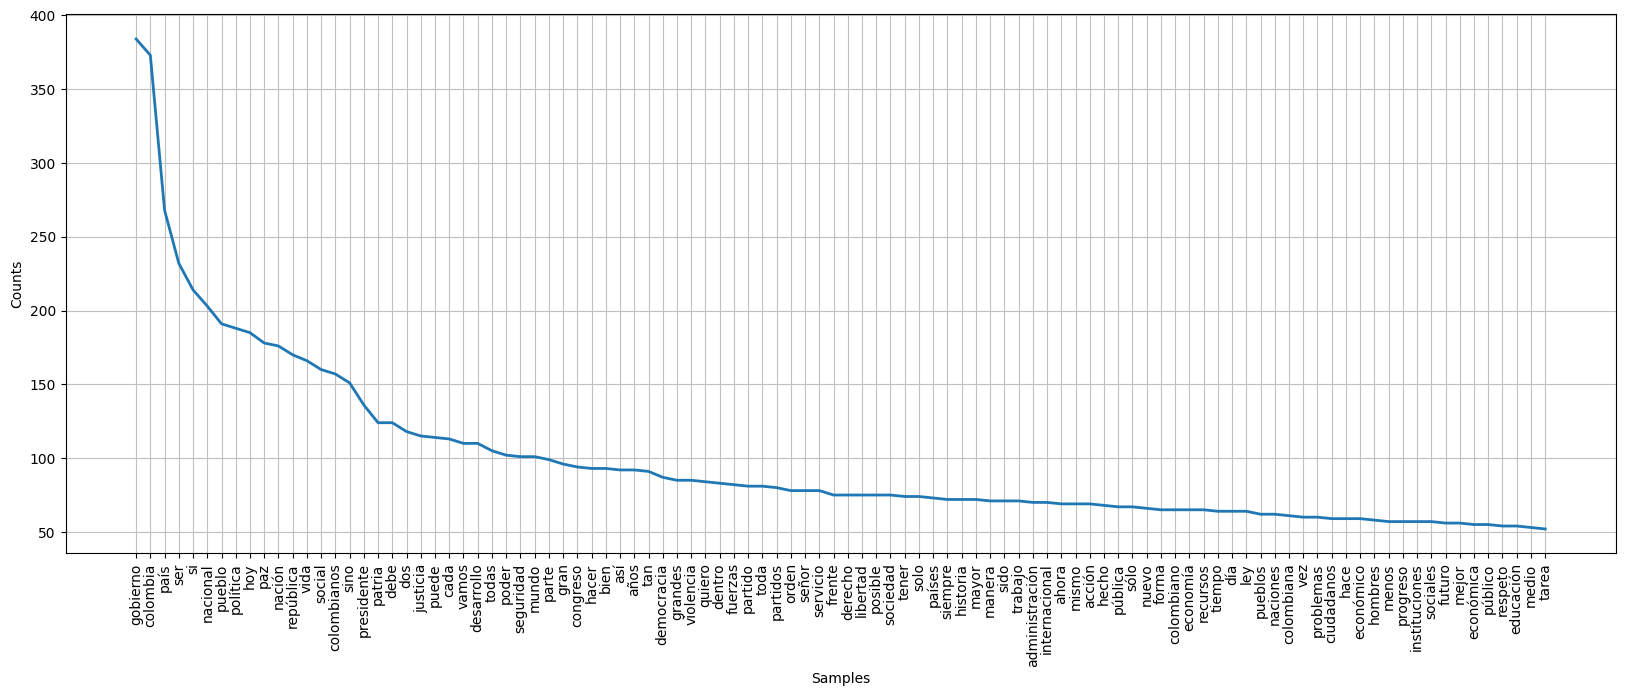

In [17]:
from nltk import FreqDist

frecuencias = FreqDist(tokens_discursos)
fig = plt.figure(figsize = (20, 7))
frecuencias.plot(100)

### Diversidad Lexica de los discursos

Tokenizando cada discurso por separado 

In [27]:
def limpiar(texto):
    return [
        word.lower()
        for word in word_tokenize(texto, "spanish")
        if word.lower() not in list_sw and word.isalnum()
    ]

datos_con_tokens = [
    {**item, "tokens": limpiar(item["text"])}
    for item in datos
]

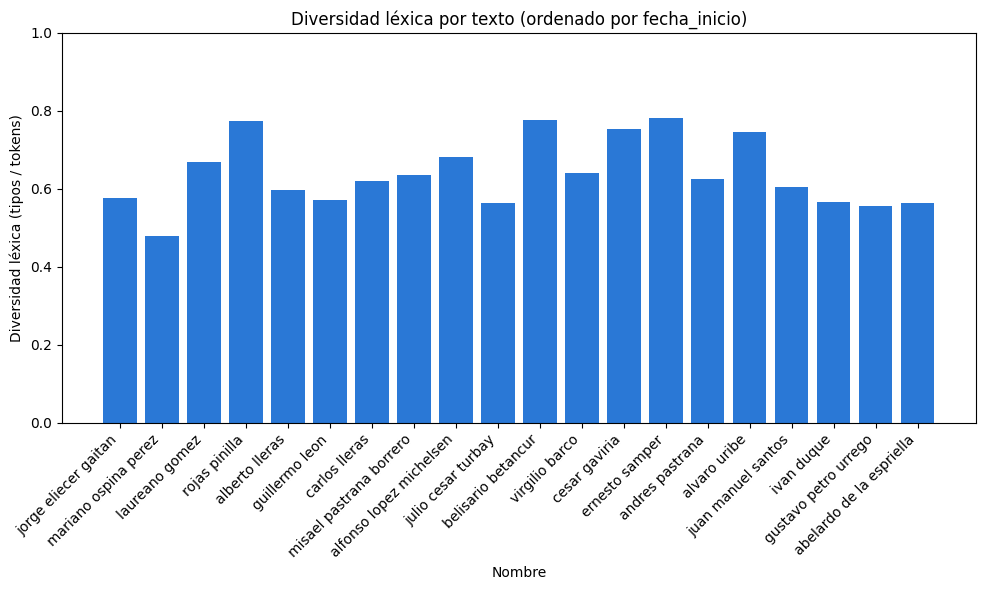

In [28]:
datos_ordenados = sorted(datos_con_tokens, key=lambda item: item["fecha_inicio"])

nombres = [item["nombre"] for item in datos_ordenados]
diversidad = [
    len(set(item["tokens"])) / len(item["tokens"]) if item["tokens"] else 0
    for item in datos_ordenados
]

# Gráfica
plt.figure(figsize=(10, 6))
plt.bar(nombres, diversidad, color="#2a78d6")
plt.xlabel("Nombre")
plt.ylabel("Diversidad léxica (tipos / tokens)")
plt.title("Diversidad léxica por texto (ordenado por fecha_inicio)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()